In [290]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [291]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [293]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")
print("Shape:", df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [294]:
df.info()
print("-----------------------------------")
df.isnull().sum()
print("---------Describe---------------")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
-----------------------------------
---------Describe---------------
              Year        Month  Estimated_Del

In [295]:
from sklearn.preprocessing import LabelEncoder
df_ml = df.copy()

le_region= LabelEncoder()
le_model=LabelEncoder()
le_source= LabelEncoder()

df_ml["Region"] = le_region.fit_transform(df_ml["Region"])
df_ml["Model"]=le_model.fit_transform(df_ml["Model"])
df_ml["Source_Type"] = le_source.fit_transform(df_ml["Source_Type"])

print("Before Encoding")
print(df[["Region","Model","Source_Type"]])
print("\n")
print("After Encoding")
print(df_ml[["Region","Model","Source_Type"]])

Before Encoding
             Region       Model           Source_Type
0            Europe     Model S  Interpolated (Month)
1              Asia     Model X    Official (Quarter)
2     North America     Model X  Interpolated (Month)
3     North America     Model 3    Official (Quarter)
4       Middle East     Model Y    Estimated (Region)
...             ...         ...                   ...
2635    Middle East     Model Y    Official (Quarter)
2636    Middle East     Model S    Official (Quarter)
2637           Asia     Model S    Estimated (Region)
2638           Asia  Cybertruck  Interpolated (Month)
2639  North America     Model S    Estimated (Region)

[2640 rows x 3 columns]


After Encoding
      Region  Model  Source_Type
0          1      2            1
1          0      3            2
2          3      3            1
3          3      1            2
4          2      4            0
...      ...    ...          ...
2635       2      4            2
2636       2      2           

In [296]:
from sklearn.preprocessing import StandardScaler

features = [
    "Production_Units",
    "CO2_Saved_tons",
    "Avg_Price_USD",
    "Charging_Stations",
    "Region",
    "Model"
]

X = df_ml[features].copy()

y = df_ml["Estimated_Deliveries"]

numerical_cols = [
    "Production_Units",
    "CO2_Saved_tons",
    "Avg_Price_USD",
    "Charging_Stations"
]

scaler = StandardScaler()

X.loc[:, numerical_cols] = scaler.fit_transform(
    X[numerical_cols]
)

print(X.head())

   Production_Units  CO2_Saved_tons  Avg_Price_USD  Charging_Stations  Region  \
0          1.705752        3.169558       0.395982           0.944062       1   
1         -1.523982       -1.400569      -1.128346          -0.372490       0   
2         -0.344347       -0.392143       1.639209           1.481407       3   
3         -0.785213       -0.124611       0.218076           0.115560       3   
4          0.676360        1.367116       1.488085          -0.060576       2   

   Model  
0      2  
1      3  
2      3  
3      1  
4      4  


In [297]:

print("-------------Region------------------")
print(df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False))


print("-------------Model---------------------")
print(df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False))


print("-------------Year----------------------")
print(df.groupby("Year")["Estimated_Deliveries"].sum())

-------------Region------------------
Region
Middle East      6698045
Asia             6539935
Europe           6494035
North America    6462592
Name: Estimated_Deliveries, dtype: int64
-------------Model---------------------
Model
Model S       5380385
Model 3       5321919
Model Y       5225284
Model X       5157240
Cybertruck    5109779
Name: Estimated_Deliveries, dtype: int64
-------------Year----------------------
Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64


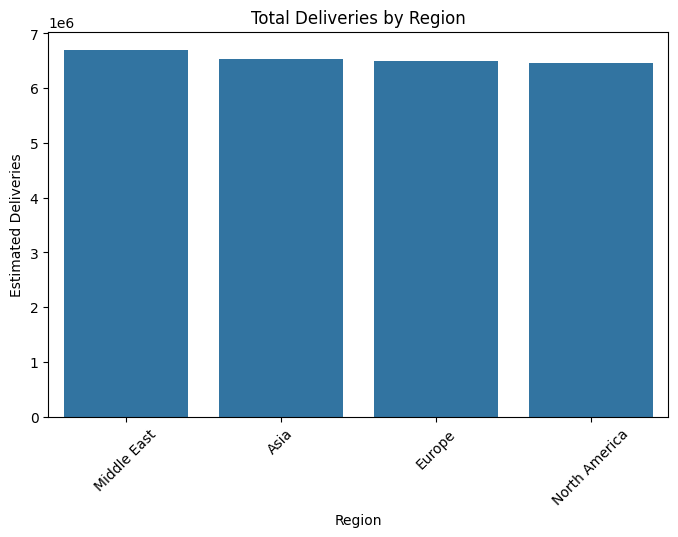

In [298]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

region_sales = (df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False))

sns.barplot(x=region_sales.index,y=region_sales.values)

plt.title("Total Deliveries by Region")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=45)

plt.show()

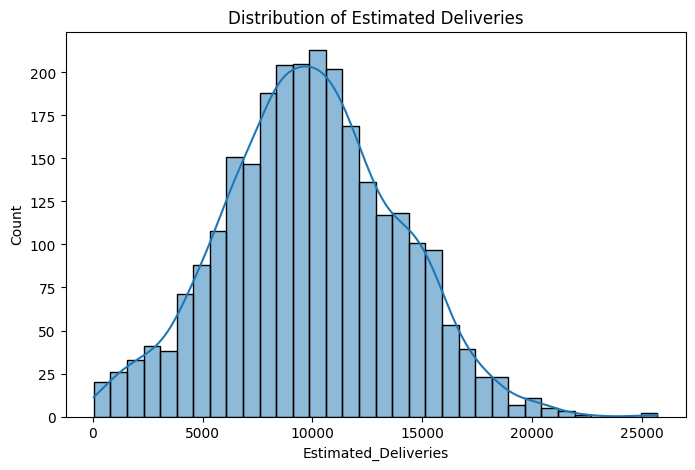

In [299]:
plt.figure(figsize=(8,5))

sns.histplot(df["Estimated_Deliveries"],kde=True)

plt.title("Distribution of Estimated Deliveries")
plt.show()

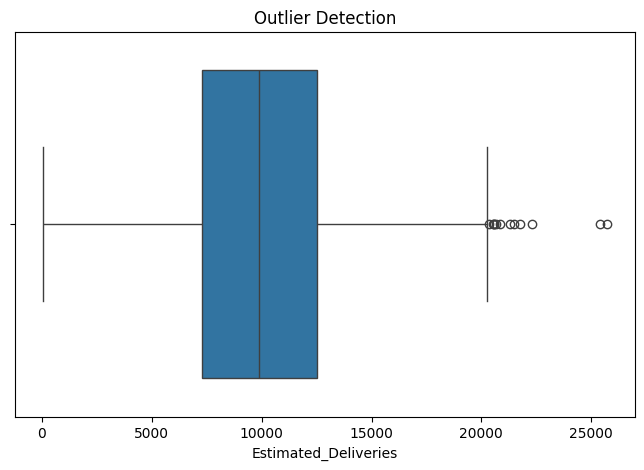

In [300]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Estimated_Deliveries"])

plt.title("Outlier Detection")
plt.show()

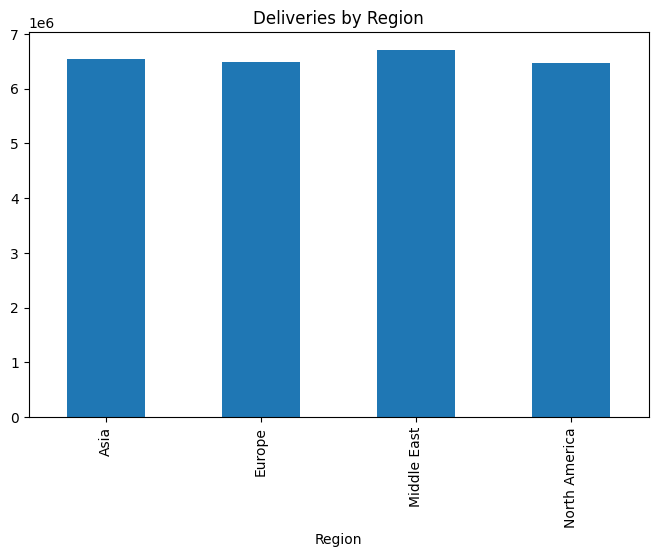

In [301]:
region_sales = df.groupby("Region")[
    "Estimated_Deliveries"
].sum()

region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Deliveries by Region")
plt.show()

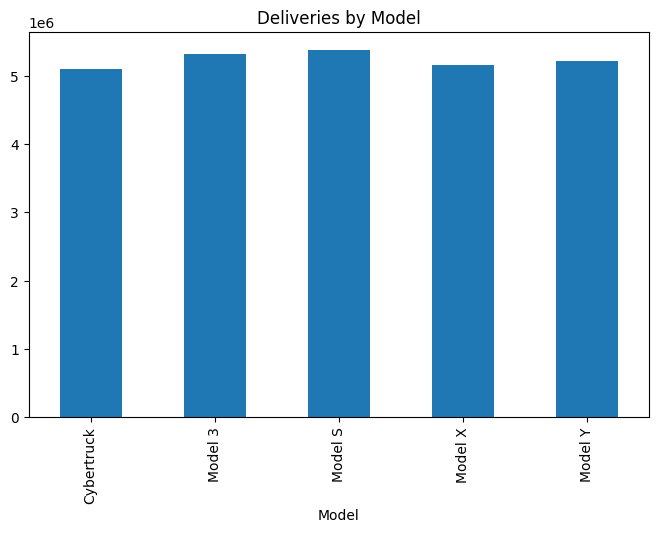

In [302]:
model_sales = df.groupby("Model")[
    "Estimated_Deliveries"
].sum()

model_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Deliveries by Model")
plt.show()

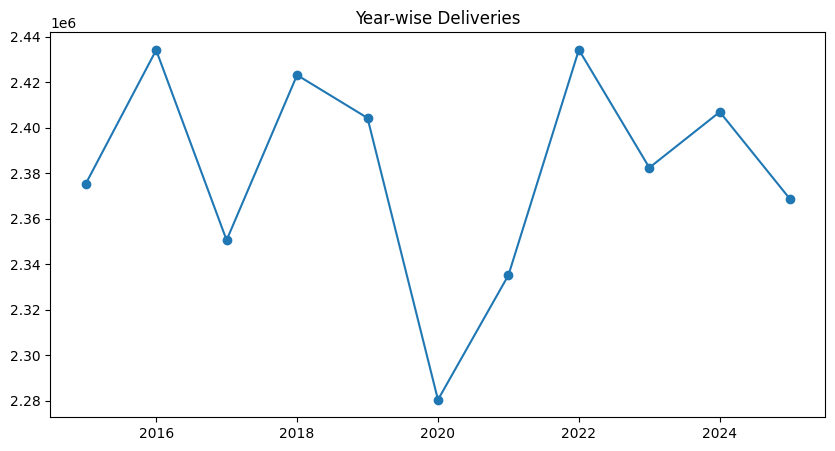

In [303]:
year_sales = df.groupby("Year")[
    "Estimated_Deliveries"
].sum()

plt.figure(figsize=(10,5))

plt.plot(
    year_sales.index,
    year_sales.values,
    marker="o"
)

plt.title("Year-wise Deliveries")
plt.show()

Top Correlations with Estimated Deliveries 
Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Model                   0.004515
Charging_Stations       0.000753
Region                 -0.001206
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Source_Type            -0.013190
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


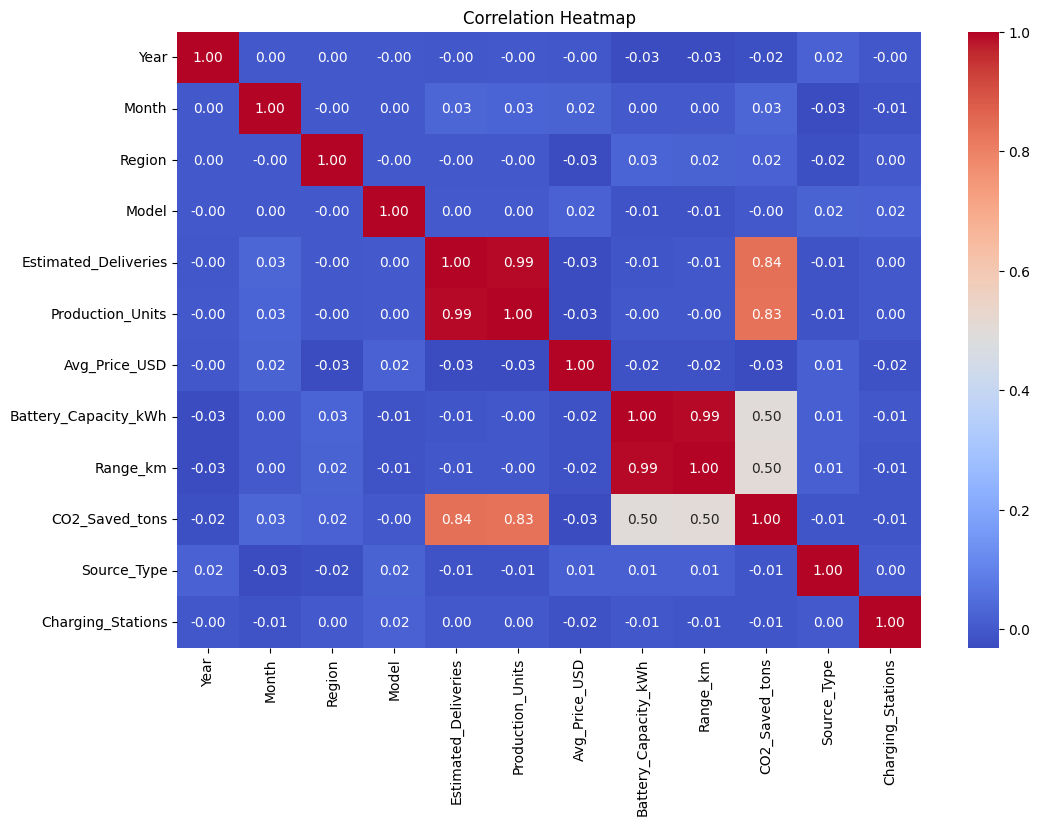

In [304]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_ml.corr(numeric_only=True)

print("Top Correlations with Estimated Deliveries ")
print(corr["Estimated_Deliveries"].sort_values(ascending=False))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


Only two Features 'Production_Units'  and 'CO2_Saved_tons' has more corelation with Estimated Deliveries , Remaining all features has weaker Co-relations

In [305]:
#7.Feature Engineering
import numpy as np

# 1. Engineered Features
df_ml["Battery_Efficiency"] = df_ml["Range_km"] / df_ml["Battery_Capacity_kWh"]
df_ml["Price_per_Range"] = df_ml["Avg_Price_USD"] / df_ml["Range_km"]
df_ml["Month_sin"] = np.sin(2 * np.pi * df_ml["Month"] / 12)
df_ml["Month_cos"] = np.cos(2 * np.pi * df_ml["Month"] / 12)
df_ml["Charging_Per_Range"] = df_ml["Charging_Stations"] / df_ml["Range_km"]

# 2. Define features list
engineered_features = [
    "Battery_Efficiency",
    "Price_per_Range",
    "Month_sin",
    "Month_cos",
    "Charging_Per_Range"
]

# 3. Print Correlation Matrix
print(df_ml[engineered_features + ["Estimated_Deliveries"]].corr()["Estimated_Deliveries"])


Battery_Efficiency      0.014403
Price_per_Range        -0.019372
Month_sin              -0.032427
Month_cos               0.016524
Charging_Per_Range      0.006827
Estimated_Deliveries    1.000000
Name: Estimated_Deliveries, dtype: float64


new Features have less co-relation i.e < 0.2 so its better to avoid them , Selected the Features based on Co-relations 

In [306]:
# features evaluated and selected these features
features = [
    "Production_Units",
    "CO2_Saved_tons",
    "Avg_Price_USD",
    "Charging_Stations",
    "Region",
    "Model"
]
#features = df_ml.drop("Estimated_Deliveries",axis = 1)
X = df_ml[features]
y = df_ml["Estimated_Deliveries"]

In [307]:
from sklearn.preprocessing import StandardScaler

X = df_ml[features].copy()
y = df_ml["Estimated_Deliveries"]
numerical_cols = ["Production_Units","CO2_Saved_tons","Avg_Price_USD","Charging_Stations"]
scaler = StandardScaler()
X.loc[:, numerical_cols] = scaler.fit_transform(X[numerical_cols])
print(X.head())

   Production_Units  CO2_Saved_tons  Avg_Price_USD  Charging_Stations  Region  \
0          1.705752        3.169558       0.395982           0.944062       1   
1         -1.523982       -1.400569      -1.128346          -0.372490       0   
2         -0.344347       -0.392143       1.639209           1.481407       3   
3         -0.785213       -0.124611       0.218076           0.115560       3   
4          0.676360        1.367116       1.488085          -0.060576       2   

   Model  
0      2  
1      3  
2      3  
3      1  
4      4  


In [308]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(2112, 6)
(528, 6)


In [309]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)


lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("===== Linear Regression =====")

print("R² Score:",r2_score(y_test, pred_lr))
print("MAE:",mean_absolute_error(y_test,pred_lr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_lr)))

===== Linear Regression =====
R² Score: 0.9884975963554914
MAE: 337.98844604514363
RMSE: 414.0750450782962


In [310]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200,random_state=42)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("===== Random Forest =====")
print("R² Score:",r2_score(y_test, pred_rf))
print("MAE:",mean_absolute_error(y_test,pred_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_rf)))

===== Random Forest =====
R² Score: 0.9882568833268155
MAE: 328.8830681818182
RMSE: 418.3853256504131


In [311]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200,learning_rate=0.1,max_depth=6,random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
print("===== XGBoost =====")
print("R² Score:",r2_score(y_test, pred_xgb))
print("MAE:",mean_absolute_error(y_test,pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error( y_test, pred_xgb)))

===== XGBoost =====
R² Score: 0.9875543117523193
MAE: 334.8800964355469
RMSE: 430.7194562589436


In [312]:
comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "R2": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_xgb)
    ],

    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_xgb)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_xgb))
    ]
})

comparison = comparison.sort_values(
    by="R2",
    ascending=False
)

print(comparison)

               Model        R2         MAE        RMSE
0  Linear Regression  0.988498  337.988446  414.075045
1      Random Forest  0.988257  328.883068  418.385326
2            XGBoost  0.987554  334.880096  430.719456


In [313]:
print('CROSS-VALIDATION for ALL Models' )
from sklearn.model_selection import cross_val_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200,learning_rate=0.1,max_depth=6,random_state=42)}

for name, model in models.items():
    scores = cross_val_score(model,X,y,cv=5,scoring="r2" )
    print("\n", name)
    print("CV Scores:", scores)
    print("Average R²:", scores.mean())
    print("Std:", scores.std())

CROSS-VALIDATION for ALL Models

 Linear Regression
CV Scores: [0.98879497 0.98851668 0.98760014 0.98867905 0.98947854]
Average R²: 0.9886138757231346
Std: 0.0006036218045777788

 Random Forest
CV Scores: [0.98762092 0.988918   0.9866721  0.98881377 0.99010228]
Average R²: 0.9884254123668719
Std: 0.001177002873536157

 XGBoost
CV Scores: [0.98544788 0.98694313 0.98211914 0.98895413 0.98557884]
Average R²: 0.9858086228370666
Std: 0.0022350162791746134


In [314]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)
import numpy as np

# Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

print("Ridge Regression (L2)")
print("R² Score:",r2_score(y_test, pred_ridge))
print("MAE:",mean_absolute_error(y_test, pred_ridge))
print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_ridge)))


# Lasso Regression (L1)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

print("\nLasso Regression (L1)")
print("R² Score:",r2_score(y_test, pred_lasso))
print("MAE:",mean_absolute_error(y_test, pred_lasso))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_lasso)))

Ridge Regression (L2)
R² Score: 0.9884898510828851
MAE: 338.1561986593
RMSE: 414.21443265745444

Lasso Regression (L1)
R² Score: 0.9885099062902004
MAE: 337.86718091941776
RMSE: 413.8534130859755


In [315]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression (L2)",
        "Lasso Regression (L1)"
    ],
    "R2": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_lasso)
    ],
    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_ridge),
        mean_absolute_error(y_test, pred_lasso)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_ridge)),
        np.sqrt(mean_squared_error(y_test, pred_lasso))
    ]
})

print(comparison)

                   Model        R2         MAE        RMSE
0      Linear Regression  0.988498  337.988446  414.075045
1  Ridge Regression (L2)  0.988490  338.156199  414.214433
2  Lasso Regression (L1)  0.988510  337.867181  413.853413


ALL 3 Models performed very well with slight approx 0.0002 difference , Lasso Regression is slightly BEST.
this indicates Low multicollinearity,Strong linear relationship between traget and features


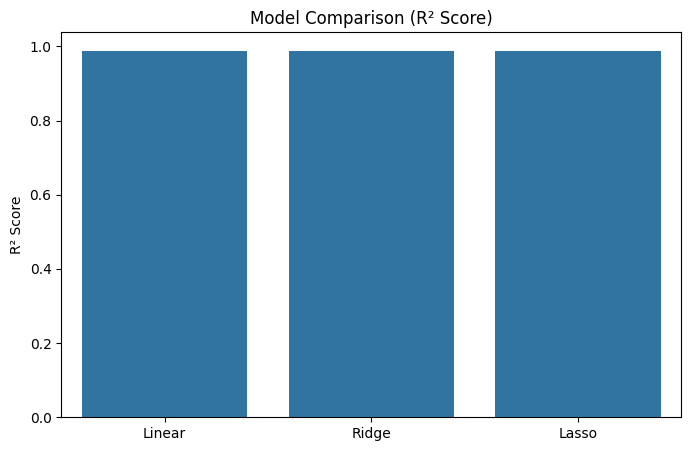

In [316]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ["Linear","Ridge","Lasso"]
r2_scores = [0.988498,0.988490,0.988510]

plt.figure(figsize=(8,5))
sns.barplot(x=models,y=r2_scores)
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")

plt.show()

In [317]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coef_df)

             Feature       Linear        Ridge        Lasso
0   Production_Units  3822.222334  3816.465845  3822.504907
1     CO2_Saved_tons   102.938525   107.714292   101.675397
2      Avg_Price_USD    14.571644    14.546325    13.532396
3  Charging_Stations     6.204901     6.256790     5.182768
4             Region     0.466934     0.395629     0.000000
5              Model     6.691940     6.743968     6.216477


In [318]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

pipeline = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=1.0))])
pipeline.fit(X_train, y_train)
pred_pipe = pipeline.predict(X_test)

print("Pipeline Results")
print("R²:",r2_score(y_test, pred_pipe))
print("MAE:",mean_absolute_error(y_test, pred_pipe))
print("RMSE:",np.sqrt(mean_squared_error(y_test, pred_pipe )))

Pipeline Results
R²: 0.9885118686620261
MAE: 337.8448645447731
RMSE: 413.8180709479126


In [319]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipeline,X,y,cv=5, scoring="r2")

print("CV Scores:")
print(scores)

print("\nAverage R²:")
print(scores.mean())

print("\nStd:")
print(scores.std())

CV Scores:
[0.98880676 0.98851256 0.98760246 0.9886848  0.9894844 ]

Average R²:
0.988618195475406

Std:
0.0006055043933084412


In [320]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

param_grid = {"alpha": [ 0.0001, 0.001, 0.01,0.1, 1,10]}
grid = GridSearchCV(Lasso(),param_grid,cv=5,scoring="r2")
grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Score:")
print(grid.best_score_)

Best Parameters:
{'alpha': 10}
Best Score:
0.988618284700185


In [321]:
"""TIME SERIES DATA FORECASTING"""

'TIME SERIES DATA FORECASTING'

In [322]:
import pandas as pd

monthly = (df.groupby(["Year", "Month"])["Estimated_Deliveries"].sum().reset_index())
monthly["Date"] = pd.to_datetime(monthly["Year"].astype(str) + "-" + monthly["Month"].astype(str) + "-01")

monthly = monthly.sort_values("Date")
monthly.set_index("Date", inplace=True)
ts = monthly["Estimated_Deliveries"]
print(f"Time Series Length: {len(ts)} months")
print(ts.head())


Time Series Length: 132 months
Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64


In [323]:
print("ARIMA MODEL")
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(ts,order=(1,1,1))
arima_fit = arima_model.fit()

print(arima_fit.summary())

ARIMA MODEL
                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1488.634
Date:                  Mon, 08 Jun 2026   AIC                           2983.269
Time:                          15:19:16   BIC                           2991.895
Sample:                      01-01-2015   HQIC                          2986.774
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1592      0.074      2.158      0.031       0.015       0.304
ma.L1         -0.7277      0.063    -11.529      0.000      -0.851      -0.604
sigma2       3.58e+08   

In [324]:

forecast_arima = arima_fit.forecast(steps=12)
print(forecast_arima)


2026-01-01    201130.711312
2026-02-01    199815.368230
2026-03-01    199605.917024
2026-04-01    199572.564655
2026-05-01    199567.253726
2026-06-01    199566.408030
2026-07-01    199566.273364
2026-08-01    199566.251920
2026-09-01    199566.248506
2026-10-01    199566.247962
2026-11-01    199566.247875
2026-12-01    199566.247862
Freq: MS, Name: predicted_mean, dtype: float64


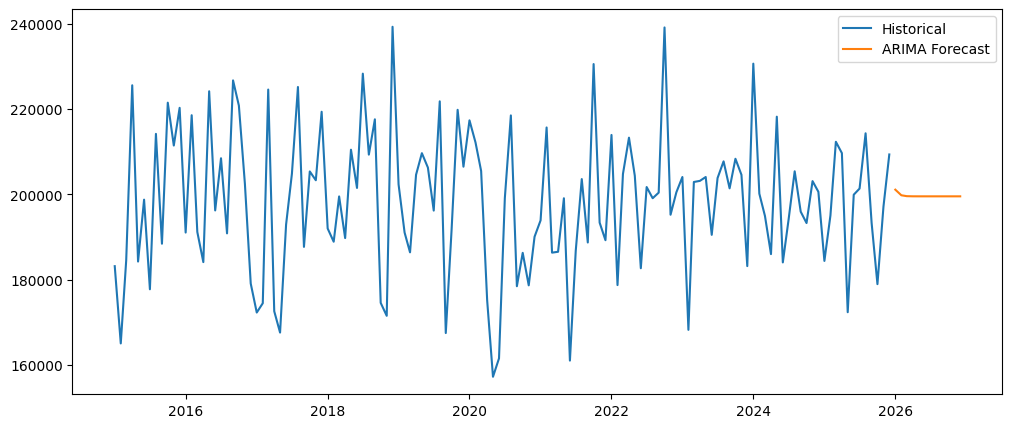

In [325]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(ts,label="Historical")
plt.plot(forecast_arima,label="ARIMA Forecast")
plt.legend()
plt.show()

In [326]:
print("Evaluation ")
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

train = ts[:-12]
test = ts[-12:]

arima_model = ARIMA( train,order=(1,1,1))
arima_fit = arima_model.fit()
print(arima_fit.summary())
pred_arima = arima_fit.forecast(steps=len(test))
arima_mae = mean_absolute_error(test,pred_arima)
arima_rmse = np.sqrt(mean_squared_error(test,pred_arima))

print("\nARIMA Results")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  120
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1354.986
Date:                  Mon, 08 Jun 2026   AIC                           2715.973
Time:                          15:19:16   BIC                           2724.310
Sample:                      01-01-2015   HQIC                          2719.358
                           - 12-01-2024                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1370      0.083      1.654      0.098      -0.025       0.299
ma.L1         -0.6795      0.071     -9.625      0.000      -0.818      -0.541
sigma2      3.745e+08   2.33e-11    

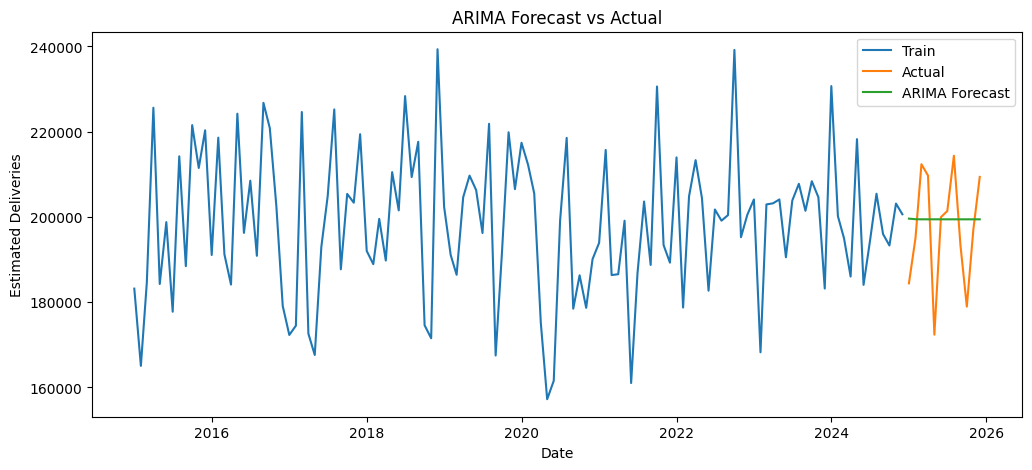

In [327]:
plt.figure(figsize=(12,5))

plt.plot(
    train.index,
    train.values,
    label="Train"
)

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    pred_arima,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()
plt.show()

In [328]:
print("SARIMAX MODEL")

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(ts,order=(1,1,1),seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit()
print(sarima_fit.summary())

SARIMAX MODEL
                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  132
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1367.670
Date:                            Mon, 08 Jun 2026   AIC                           2745.339
Time:                                    15:19:17   BIC                           2759.235
Sample:                                01-01-2015   HQIC                          2750.982
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0018      0.220      0.008      0.994      -0.430       0.433
ma.L1         -0.4318

In [329]:
forecast_sarima = sarima_fit.forecast(steps=12)
print(forecast_sarima)

2026-01-01    209863.462954
2026-02-01    204851.343377
2026-03-01    214175.917824
2026-04-01    210741.690015
2026-05-01    203974.550949
2026-06-01    202763.872521
2026-07-01    212260.120366
2026-08-01    221964.724652
2026-09-01    206888.722562
2026-10-01    211178.268678
2026-11-01    210143.713289
2026-12-01    216278.841721
Freq: MS, Name: predicted_mean, dtype: float64


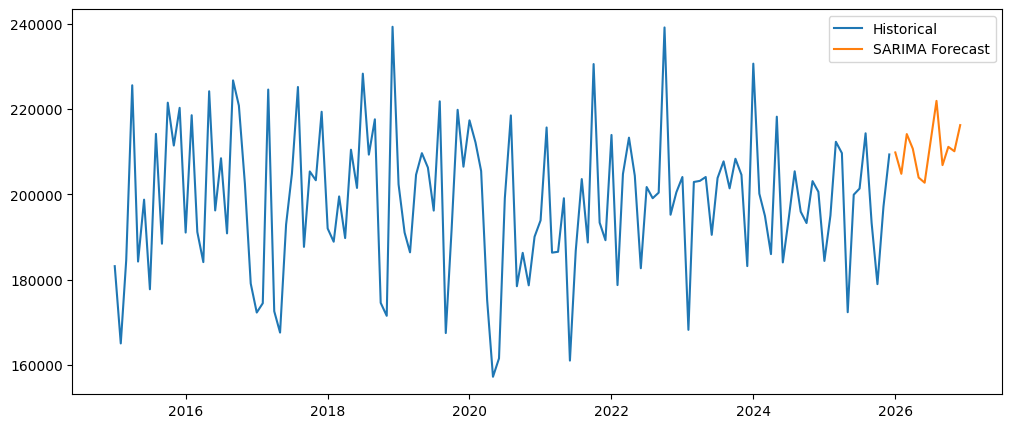

In [330]:
plt.figure(figsize=(12,5))
plt.plot(ts,label="Historical")
plt.plot(forecast_sarima,label="SARIMA Forecast")
plt.legend()
plt.show()

In [331]:
monthly_exog = df.groupby(["Year","Month"])[["Production_Units","Avg_Price_USD"]].mean()
monthly_exog.index = ts.index

In [332]:
monthly_exog = df.groupby(["Year","Month"])[["Production_Units","Avg_Price_USD"]].mean()
monthly_exog.index = ts.index

In [333]:
future_exog = pd.DataFrame({
    "Production_Units":[monthly_exog["Production_Units"].mean()]*12,
    "Avg_Price_USD":[monthly_exog["Avg_Price_USD"].mean()]*12})

forecast_sarimax = sarimax_fit.forecast(steps=12,exog=future_exog)
print(forecast_sarimax)

2025-01-01    198363.285763
2025-02-01    197745.205681
2025-03-01    197683.908407
2025-04-01    197816.401245
2025-05-01    197930.413163
2025-06-01    198014.652048
2025-07-01    198464.227388
2025-08-01    198306.464138
2025-09-01    197921.630312
2025-10-01    198505.059917
2025-11-01    198796.487643
2025-12-01    197964.977385
Freq: MS, Name: predicted_mean, dtype: float64


In [334]:
train = ts[:-12]
test = ts[-12:]

In [335]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_model = SARIMAX(train,order=(1,1,1),seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit(disp=False)
pred_sarima = sarima_fit.forecast(steps=len(test))
sarima_mae = mean_absolute_error(test,pred_sarima)
sarima_rmse = np.sqrt(mean_squared_error(test,pred_sarima))

print("SARIMA MAE :", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)

SARIMA MAE : 15109.869133982696
SARIMA RMSE: 20683.908669059707


In [336]:
monthly_exog = df.groupby(["Year","Month"])[["Production_Units","Avg_Price_USD"]].mean()
monthly_exog.index = ts.index
train_exog = monthly_exog[:-12]
test_exog = monthly_exog[-12:]

sarimax_model = SARIMAX(
    train,
    exog=train_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12))

sarimax_fit = sarimax_model.fit(disp=False)

pred_sarimax = sarimax_fit.forecast(steps=len(test),exog=test_exog)

sarimax_mae = mean_absolute_error(test,pred_sarimax)

sarimax_rmse = np.sqrt(mean_squared_error(test, pred_sarimax ))

print("SARIMAX MAE :", sarimax_mae)
print("SARIMAX RMSE:", sarimax_rmse)

SARIMAX MAE : 1970.96798494213
SARIMAX RMSE: 2317.732614859997


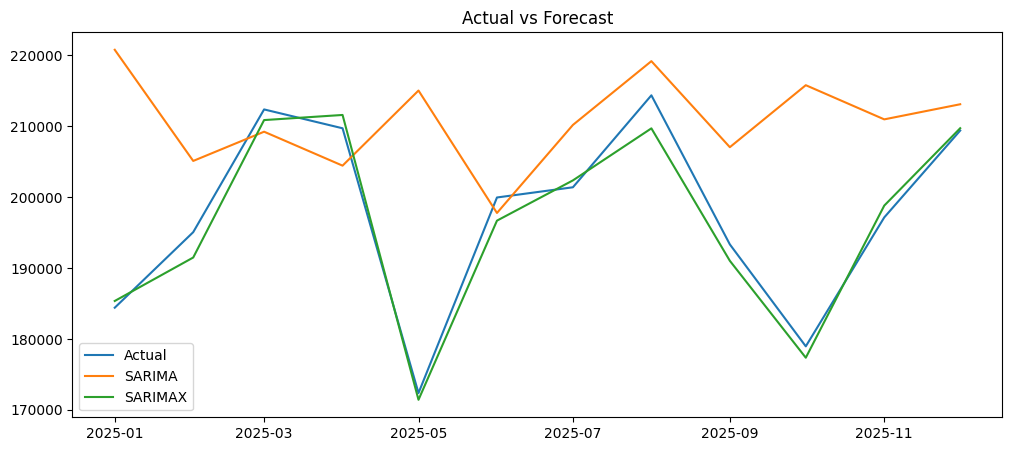

In [337]:
plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    pred_sarima,
    label="SARIMA"
)

plt.plot(
    test.index,
    pred_sarimax,
    label="SARIMAX"
)

plt.title("Actual vs Forecast")
plt.legend()
plt.show()

In [338]:
comparison_ts = pd.DataFrame({
    "Model": ["SARIMA", "SARIMAX"],
    "MAE": [sarima_mae, sarimax_mae],
    "RMSE": [sarima_rmse, sarimax_rmse]
})

print(comparison_ts)

     Model           MAE          RMSE
0   SARIMA  15109.869134  20683.908669
1  SARIMAX   1970.967985   2317.732615


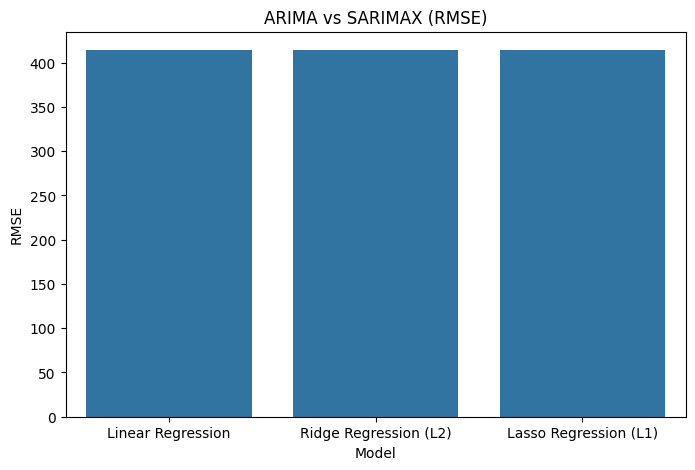

In [339]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("ARIMA vs SARIMAX (RMSE)")
plt.ylabel("RMSE")

plt.show()

The comparison of SARIMA and SARIMAX models in terms of predicting deliveries for Tesla revealed that SARIMAX provided better results with lower errors (MAE=1970.97, RMSE=2317.73), while SARIMA showed higher errors (MAE=15109.87, RMSE=20683.91). The reason for better results of SARIMAX is that it takes into account external factors like Production Units and Average Price, unlike SARIMA, which considers only the history of deliveries.